### 1. Introduction 
For our group assignment, we aim to create a machine learning model that forecasts loan defaults using past credit info. The goal is to help figure out who might not pay back their loans.

Our team includes: Group 5 
Mahima Patel NF1041573
Krupali Modi NF1045282
Surbhi Patel NF1044850
Sunhera Salomi NF1039095


### 2.Import Libraries

In [71]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [72]:
applications = pd.read_csv("creditrisk_applications_final.csv")
inquiries = pd.read_csv("creditrisk_inquiries_final.csv")

print("Applications Shape:", applications.shape)
print("Inquiries Shape:", inquiries.shape)

Applications Shape: (85000, 22)
Inquiries Shape: (45000, 8)


In [73]:
applications.head()

,application_id,requested_amount_usd,repayment_term_text,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,risk_grade_band,risk_grade_detail,employment_tenure_text,housing_status,...,origination_month,outcome_status,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text
0,41080563,18000.0,60 months,13.33,412.61,15325.62,C,C3,3 years,OWN,...,Feb-2015,Fully Paid,debt_consolidation,AZ,6.78,670.0,674.0,7.0,0.0,89.5
1,76295652,1000.0,36 months,11.99,33.21,842.45,C,C1,1 year,RENT,...,Apr-2016,Fully Paid,home_improvement,FL,11.54,690.0,694.0,3.0,1.0,13.3
2,60586596,21275.0,36 months,10.99,696.42,7380.80,B,B4,5 years,MORTGAGE,...,Sep-2015,Fully Paid,debt_consolidation,PA,23.08,680.0,684.0,13.0,0.0,75.7
3,59310389,35000.0,60 months,16.99,869.66,32305.48,D,D3,10+ years,MORTGAGE,...,Sep-2015,Fully Paid,credit_card,SC,16.3,710.0,714.0,10.0,0.0,76.5
4,44516103,17000.0,60 months,17.57,427.73,427.73,D,D4,8 years,RENT,...,Apr-2015,Charged Off,credit_card,CA,31.27,680.0,684.0,8.0,0.0,62.5


### Dataset Structure Exploration

Before data cleaning, the dataset structure was examined to understand the number of observations, variable types, and overall data quality. 
This step helps identify potential data preparation requirements and supports the exploratory data analysis process.

In [74]:
applications.info()

<class 'pandas.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   application_id              85000 non-null  int64  
 1   requested_amount_usd        85000 non-null  float64
 2   repayment_term_text         85000 non-null  str    
 3   interest_rate_text          85000 non-null  float64
 4   monthly_installment_usd     85000 non-null  float64
 5   last_payment_amount_usd     85000 non-null  float64
 6   risk_grade_band             85000 non-null  str    
 7   risk_grade_detail           85000 non-null  str    
 8   employment_tenure_text      76324 non-null  str    
 9   housing_status              85000 non-null  str    
 10  annual_income_usd           84320 non-null  float64
 11  income_verification_status  85000 non-null  str    
 12  origination_month           85000 non-null  str    
 13  outcome_status              85000 non-null

In [75]:
applications.isnull().sum()

application_id                   0
requested_amount_usd             0
repayment_term_text              0
interest_rate_text               0
monthly_installment_usd          0
last_payment_amount_usd          0
risk_grade_band                  0
risk_grade_detail                0
employment_tenure_text        8676
housing_status                   0
annual_income_usd              680
income_verification_status       0
origination_month                0
outcome_status                   0
loan_purpose                     0
region_code                      0
debt_to_income_ratio           709
credit_score_low                 0
credit_score_high                0
open_credit_lines                0
public_records_count             0
revolving_utilization_text     892
dtype: int64

## 3.Data Cleaning and Target Variable Creation
Before building the machine learning model, the data needs cleaning and prep.

we looked for missing values and duplicates, and got rid of them.

Then, we made the target variable for predicting loan defaults using the `outcome_status` column. 

For `Charged Off`, I coded it as `1` for default, and everything else got a `0`.

This target variable is key for the classification models later on.

In [76]:
# Checking the number of missing values in each column
# This helps us understand which variables need cleaning before analysis

missing_values = applications.isnull().sum()

missing_values

application_id                   0
requested_amount_usd             0
repayment_term_text              0
interest_rate_text               0
monthly_installment_usd          0
last_payment_amount_usd          0
risk_grade_band                  0
risk_grade_detail                0
employment_tenure_text        8676
housing_status                   0
annual_income_usd              680
income_verification_status       0
origination_month                0
outcome_status                   0
loan_purpose                     0
region_code                      0
debt_to_income_ratio           709
credit_score_low                 0
credit_score_high                0
open_credit_lines                0
public_records_count             0
revolving_utilization_text     892
dtype: int64

In [77]:
# Checking duplicate records
# Duplicate rows can affect model accuracy, so they should be removed

duplicate_count = applications.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [78]:
# Removing duplicate rows from the dataset
# If there are no duplicates, the shape will remain the same

applications = applications.drop_duplicates()

print("Shape after removing duplicates:", applications.shape)

cleaning_summary = pd.DataFrame({
    "Step": ["Original records", "Duplicate rows removed", "Records after cleaning"],
    "Count": [len(applications) + duplicate_count, duplicate_count, len(applications)]
})

cleaning_summary

Shape after removing duplicates: (85000, 22)


,Step,Count
0,Original records,85000
1,Duplicate rows removed,0
2,Records after cleaning,85000


In [79]:
# Checking all unique loan outcome statuses
# This is important before creating the target variable

applications["outcome_status"].value_counts()

outcome_status
Fully Paid     42500
Charged Off    42500
Name: count, dtype: int64

In [80]:
# Creating binary target variable for default prediction
# Charged Off means the borrower failed to repay the loan, so it is coded as 1
# All other outcomes are coded as 0

applications["target_default"] = applications["outcome_status"].apply(
    lambda x: 1 if x == "Charged Off" else 0
)

# Displaying first few rows to verify the new target variable
applications[["outcome_status", "target_default"]].head()

,outcome_status,target_default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
3,Fully Paid,0
4,Charged Off,1


In [81]:
# Checking the count of default and non-default loans

applications["target_default"].value_counts()

target_default
0    42500
1    42500
Name: count, dtype: int64

In [82]:
# Checking target variable distribution in percentage
# This helps us understand whether the dataset is balanced or imbalanced

applications["target_default"].value_counts(normalize=True) * 100

target_default
0    50.0
1    50.0
Name: proportion, dtype: float64

## 4. Data Understanding and Missing Value Analysis

Before we could build any predictive models, our team took a look at the dataset's structure and quality. This meant identifying missing values and understanding data types, dimensions, and summary stats. The dataset included numerical and categorical variables about borrower demographics, loan details, and credit info. Grasping these variables was key to preparing the data for machine learning.

In [83]:
# Display missing values for each column

missing_values = applications.isnull().sum()

missing_values[missing_values > 0]

employment_tenure_text        8676
annual_income_usd              680
debt_to_income_ratio           709
revolving_utilization_text     892
dtype: int64

In [84]:
# Calculate percentage of missing values

missing_percent = (
    applications.isnull().sum() /
    len(applications)
) * 100

missing_percent[missing_percent > 0].sort_values(
    ascending=False
)

employment_tenure_text        10.207059
revolving_utilization_text     1.049412
debt_to_income_ratio           0.834118
annual_income_usd              0.800000
dtype: float64

In [85]:
# Summary statistics for numerical variables

applications.describe()

,application_id,requested_amount_usd,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,annual_income_usd,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text,target_default
count,8.500000e+04,85000.000000,85000.000000,85000.000000,85000.000000,8.432000e+04,85000.000000,85000.000000,85000.000000,85000.000000,84108.000000,85000.000000
mean,6.633685e+07,14950.852647,13.600630,446.071413,3604.090989,7.434189e+04,692.034412,696.034482,11.920871,0.248718,52.342891,0.500000
std,2.482399e+07,8735.147461,4.886372,258.523612,6222.901104,7.732271e+04,29.787475,29.787839,5.670095,0.656437,24.293508,0.500003
min,3.476740e+05,1000.000000,5.310000,30.120000,0.000000,0.000000e+00,660.000000,664.000000,1.000000,0.000000,0.000000,0.000000
25%,4.881616e+07,8000.000000,9.990000,259.955000,308.220000,4.500000e+04,670.000000,674.000000,8.000000,0.000000,34.200000,0.000000
50%,6.059760e+07,13050.000000,13.180000,382.870000,598.895000,6.300000e+04,685.000000,689.000000,11.000000,0.000000,52.800000,0.500000
75%,7.635120e+07,20000.000000,16.550000,587.690000,4130.377500,9.000000e+04,705.000000,709.000000,15.000000,0.000000,70.900000,1.000000
max,1.411120e+08,40000.000000,30.990000,1587.230000,40551.270000,8.900060e+06,845.000000,850.000000,70.000000,49.000000,136.400000,1.000000


In [86]:
# Summary statistics for categorical variables

applications.describe(include="object")

C:\Users\dell\AppData\Local\Temp\ipykernel_28168\1745985383.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  applications.describe(include="object")


,repayment_term_text,risk_grade_band,risk_grade_detail,employment_tenure_text,housing_status,income_verification_status,origination_month,outcome_status,loan_purpose,region_code,debt_to_income_ratio
count,85000,85000,85000,76324,85000,85000,85000,85000,85000,85000,84291
unique,2,7,35,11,7,3,23,2,24,100,4391
top,36 months,C,C4,10+ years,MORTGAGE,Source Verified,Jul-2015,Fully Paid,debt_consolidation,CA,bad
freq,59223,25111,5289,26275,38111,36936,6989,42500,49344,11601,336


## 5. Data Preparation and Feature Engineering

After taking a look at our dataset and spotting any missing values, we got the data ready for machine learning analysis.

Data prep is super important since machine learning models need clean and consistent data. If there are missing values, it could tank the performance of the models and give us some really bad predictions.

To fix this:

We filled in missing numerical values with the median.
For missing categorical info, we used the category "Unknown".
We also made a copy of the original dataset to keep things consistent.
Plus, we ran data quality checks to make sure there weren't any more missing values hiding around.

All of these steps help bump up the quality of our data while keeping every observation intact.

In [87]:
# Creating a copy of the original dataset
# This allows us to keep the original dataset unchanged

df = applications.copy()

print("Dataset copy created successfully.")

Dataset copy created successfully.


In [88]:
# Identifying numerical and categorical columns

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = df.select_dtypes(
    include=["object"]
).columns

print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 12
Number of categorical columns: 11


C:\Users\dell\AppData\Local\Temp\ipykernel_28168\3974306267.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [89]:
# Replacing missing values in numerical columns using median values
# Median is less affected by extreme values compared to mean

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Numerical missing values handled.")

Numerical missing values handled.


In [90]:
# Replacing missing values in categorical columns with "Unknown"
# This preserves records instead of deleting them

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Categorical missing values handled.")

Categorical missing values handled.


In [91]:
# Verifying that all missing values have been removed

total_missing = df.isnull().sum().sum()

print("Total remaining missing values:", total_missing)

Total remaining missing values: 0


In [92]:
# Comparing missing values before and after data preparation

print("Original dataset missing values:")
print(applications.isnull().sum().sum())

print("\nPrepared dataset missing values:")
print(df.isnull().sum().sum())

Original dataset missing values:
10957

Prepared dataset missing values:
0


In [93]:
# Missing values before and after cleaning by variable

missing_summary = pd.DataFrame({
    "Missing Before": applications.isnull().sum(),
    "Missing After": df.isnull().sum()
})

missing_summary[
    missing_summary["Missing Before"] > 0
]

,Missing Before,Missing After
employment_tenure_text,8676,0
annual_income_usd,680,0
debt_to_income_ratio,709,0
revolving_utilization_text,892,0


In [94]:
# Creating an average credit score feature
# This combines the lower and upper credit score ranges
# into a single representative credit score.

df["avg_credit_score"] = (
    df["credit_score_low"] +
    df["credit_score_high"]
) / 2

# Displaying the new feature

df[[
    "credit_score_low",
    "credit_score_high",
    "avg_credit_score"
]].head()

,credit_score_low,credit_score_high,avg_credit_score
0,670.0,674.0,672.0
1,690.0,694.0,692.0
2,680.0,684.0,682.0
3,710.0,714.0,712.0
4,680.0,684.0,682.0


In [95]:
# Summary statistics for the new feature

df["avg_credit_score"].describe()

count    85000.000000
mean       694.034447
std         29.787657
min        662.000000
25%        672.000000
50%        687.000000
75%        707.000000
max        847.500000
Name: avg_credit_score, dtype: float64

In [96]:
# Reviewing data types after data preparation

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   application_id              85000 non-null  int64  
 1   requested_amount_usd        85000 non-null  float64
 2   repayment_term_text         85000 non-null  str    
 3   interest_rate_text          85000 non-null  float64
 4   monthly_installment_usd     85000 non-null  float64
 5   last_payment_amount_usd     85000 non-null  float64
 6   risk_grade_band             85000 non-null  str    
 7   risk_grade_detail           85000 non-null  str    
 8   employment_tenure_text      85000 non-null  str    
 9   housing_status              85000 non-null  str    
 10  annual_income_usd           85000 non-null  float64
 11  income_verification_status  85000 non-null  str    
 12  origination_month           85000 non-null  str    
 13  outcome_status              85000 non-null

In [97]:
# Convert debt-to-income ratio to numeric

df["debt_to_income_ratio"] = pd.to_numeric(
    df["debt_to_income_ratio"],
    errors="coerce"
)

# Fill any conversion-related missing values

df["debt_to_income_ratio"] = (
    df["debt_to_income_ratio"]
    .fillna(df["debt_to_income_ratio"].median())
)

print(df["debt_to_income_ratio"].dtype)

float64


## 6. Exploratory Data Analysis (EDA)

Here we dive into the cleaned data using visuals and stats. The goal? To spot patterns, trends, and connections between borrower traits and loan default results.

This involves examining loan amounts, incomes, and credit scores. We also look at risk grades and housing statuses, plus how these variables relate to each other.

### Visualization 1: Distribution of Requested Loan Amounts

This histogram shows the distribution of requested loan amounts among borrowers in the dataset.

The purpose of this visualization is to understand the borrowing patterns of applicants and identify the most common loan amount ranges. Loan amount is an important variable because larger loans may be associated with higher financial risk and could potentially influence loan repayment behavior.

By examining the distribution, we can determine whether borrowers tend to request smaller, medium-sized, or larger loans and identify any unusual patterns in the data.

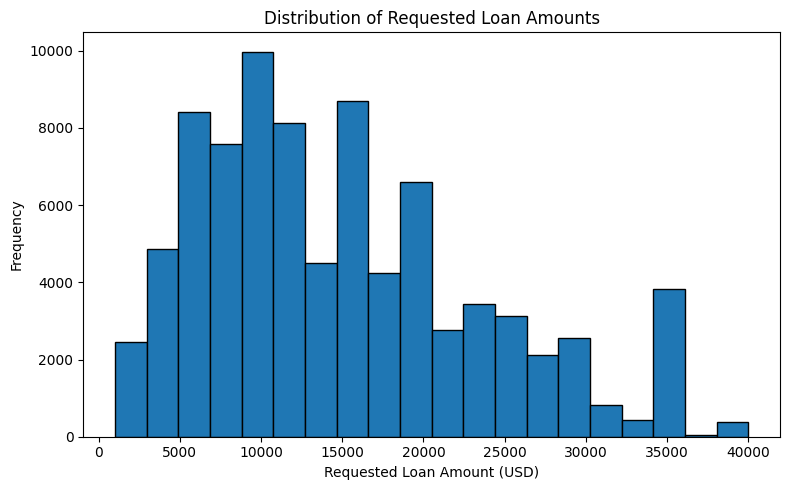

In [98]:
# Visualization 1: Distribution of Requested Loan Amounts
# This visualization helps us understand the borrowing patterns
# of applicants and identify common loan amount ranges.

plt.figure(figsize=(8,5))

plt.hist(
    df["requested_amount_usd"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Requested Loan Amounts")
plt.xlabel("Requested Loan Amount (USD)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Visualization 2: Annual Income Distribution
Distribution of Annual Income

This visualization examines the distribution of borrower annual income levels. Understanding income distribution helps identify the financial characteristics of borrowers and potential relationships with loan default risk.

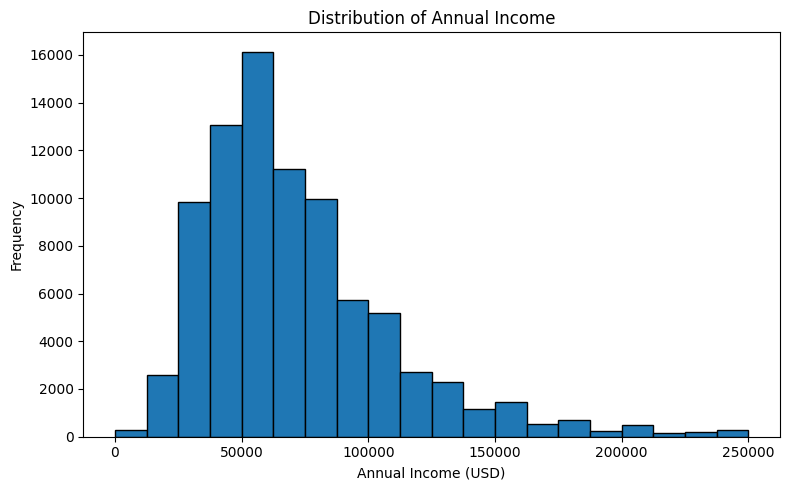

In [99]:
# Visualization 2: Annual Income Distribution
# Annual income distribution after removing extreme outliers

plt.figure(figsize=(8,5))

income_filtered = df[
    df["annual_income_usd"] <= df["annual_income_usd"].quantile(0.99)
]

plt.hist(
    income_filtered["annual_income_usd"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Visualization 3: Average Loan Amount by Risk Grade
Average Loan Amount by Risk Grade

This chart compares the average requested loan amount across borrower risk grades. It helps identify whether higher-risk borrowers tend to request larger or smaller loan amounts.

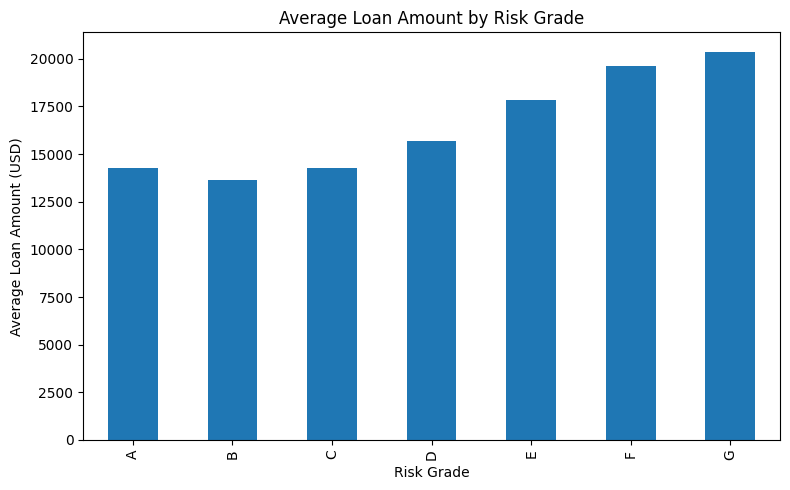

In [100]:
# Visualization 3: Average Loan Amount by Risk Grade
# Average loan amount by risk grade

risk_grade_avg = df.groupby(
    "risk_grade_band"
)["requested_amount_usd"].mean()

risk_grade_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Loan Amount by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Average Loan Amount (USD)")

plt.tight_layout()

plt.show()

### Visualization 4: Housing Status Visualization

This visualization looks at how housing status affects the average loan amount requested.

Where you live can impact your financial health and borrowing habits. By comparing average loan requests among different housing situations, we can figure out if homeowners, renters, or those in other housing setups usually ask for more money.


housing_status
MORTGAGE    39118
RENT        36217
OWN          9664
ANY             1
Name: count, dtype: int64


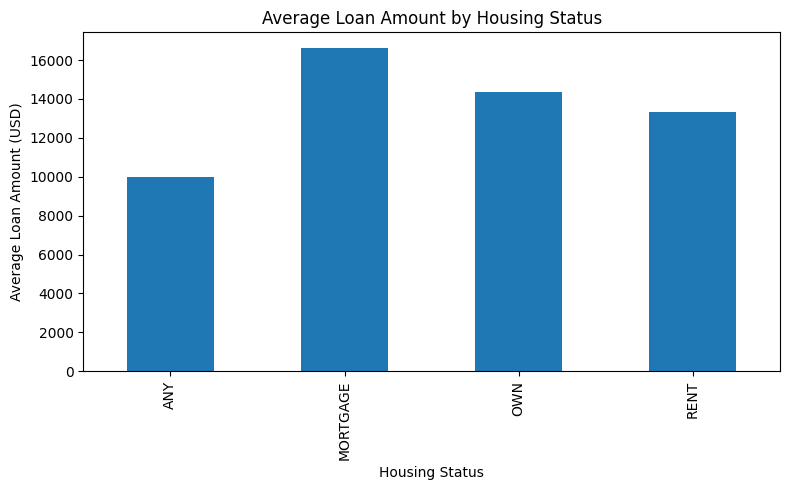

In [101]:
# Visualization 4: Average Loan Amount by Housing Status

# Standardizing housing status values
# This avoids treating "rent" and "RENT" as different categories

df["housing_status"] = df["housing_status"].str.upper()

# Checking updated housing categories

print(df["housing_status"].value_counts())

# Calculating average loan amount by housing status

housing_avg = df.groupby(
    "housing_status"
)["requested_amount_usd"].mean()

# Creating bar chart

housing_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Loan Amount by Housing Status")
plt.xlabel("Housing Status")
plt.ylabel("Average Loan Amount (USD)")

plt.tight_layout()

plt.show()

In [102]:
# Selecting only numerical variables

numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

numeric_df.columns

Index(['application_id', 'requested_amount_usd', 'interest_rate_text',
       'monthly_installment_usd', 'last_payment_amount_usd',
       'annual_income_usd', 'debt_to_income_ratio', 'credit_score_low',
       'credit_score_high', 'open_credit_lines', 'public_records_count',
       'revolving_utilization_text', 'target_default', 'avg_credit_score'],
      dtype='str')

### Visualization 5: Correlation Heatmap

A correlation heatmap was created to examine relationships among numerical variables in the dataset.

The heatmap helps identify variables that are strongly related to one another and highlights potential predictors of loan default. Correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship and values closer to -1 indicate a strong negative relationship.

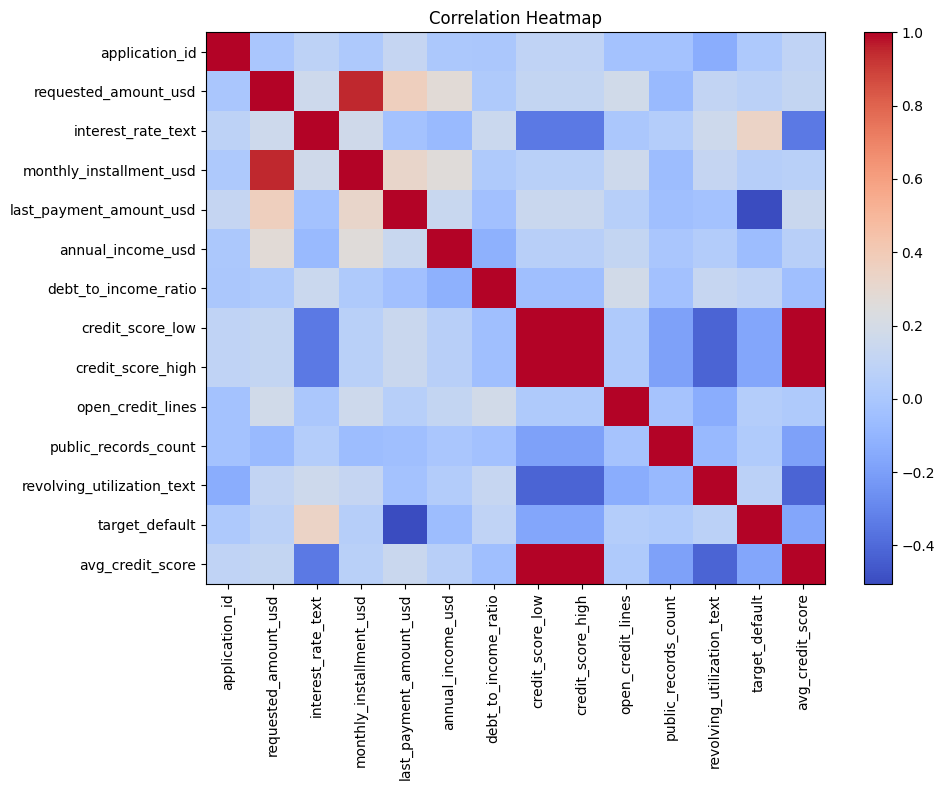

In [103]:
# Visualization 5: Correlation Heatmap
# Creating correlation matrix

correlation_matrix = numeric_df.corr()

# Plotting correlation heatmap

plt.figure(figsize=(10,8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [104]:
# Correlation with target variable

target_corr = (
    numeric_df.corr()["target_default"]
    .sort_values(ascending=False)
)

target_corr.head(10)

target_default                1.000000
interest_rate_text            0.336832
debt_to_income_ratio          0.095315
requested_amount_usd          0.073436
revolving_utilization_text    0.073147
monthly_installment_usd       0.050754
open_credit_lines             0.042734
public_records_count          0.029518
application_id                0.016182
annual_income_usd            -0.052461
Name: target_default, dtype: float64

## 7. Data Preparation for Machine Learning

Before building predictive models, the data needs to be transformed into a format that works for machine learning algorithms. The prep process includes selecting predictor variables and encoding categorical ones, plus splitting the dataset into training and testing sets. We also prepare the target variable.

This whole setup makes sure that the machine learning models can pick up on patterns in historical loan info and predict accurately.

In [105]:
# Creating a copy of the cleaned dataset for machine learning

model_df = df.copy()

# Removing identifier and data leakage variables
# application_id is only an identifier and does not contribute to prediction
# outcome_status was used to create the target variable and would reveal the answer
# last_payment_amount_usd contains post-loan information that would not be available when predicting default risk

model_df = model_df.drop(
    columns=[
        "application_id",
        "outcome_status",
        "last_payment_amount_usd"
    ],
    errors="ignore"
)

print("Shape after removing leakage and identifier variables:")
print(model_df.shape)

Shape after removing leakage and identifier variables:
(85000, 21)


In [106]:
# Verifying that leakage-related variables have been removed successfully

leakage_check = [
    col for col in model_df.columns
    if "outcome" in col.lower()
    or "payment" in col.lower()
]

print("Remaining leakage-related columns:")
print(leakage_check)

Remaining leakage-related columns:
['repayment_term_text']


### Removal of Data Leakage Variables

Before building the machine learning models, we reviewed the dataset for variables that could introduce data leakage.

Data leakage occurs when information that would not be available at the time of prediction is included in the model. To prevent unrealistic model performance, identifier fields and post-loan outcome variables were removed before model training.

In [107]:
# Checking if leakage columns still exist

[col for col in model_df.columns if 
 "outcome" in col.lower() 
 or "payment" in col.lower()]

['repayment_term_text']

In [108]:
# Converting categorical variables into numerical format
# Machine learning models require numerical inputs

model_df = pd.get_dummies(
    model_df,
    drop_first=True
)

print("Dataset Shape After Encoding:")
print(model_df.shape)

Dataset Shape After Encoding:
(85000, 213)


In [109]:
# Defining predictor variables and target variable

X = model_df.drop(
    "target_default",
    axis=1
)

y = model_df["target_default"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (85000, 212)
y Shape: (85000,)


In [110]:
# Splitting data into training and testing datasets
# Stratify keeps the same default/non-default proportion in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (68000, 212)
Testing Data: (17000, 212)


In [111]:
# Standardizing numerical features
# Logistic Regression performs better on scaled data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## 8. Logistic Regression Model

Logistic Regression was chosen first since it's widely used for binary classification problems and gives an easy-to-understand baseline for comparison.

We trained the model using the training data and then evaluated it using the testing dataset, so we could see how well it performed.

In [112]:
# Importing Logistic Regression

from sklearn.linear_model import LogisticRegression

# Creating Logistic Regression model
# max_iter increased to improve convergence

log_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

# Training the model

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [113]:
# Generating predictions on testing dataset

y_pred_log = log_model.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [114]:
# Calculating model accuracy

from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print("Logistic Regression Accuracy:")
print(round(log_accuracy, 4))

Logistic Regression Accuracy:
0.6655


In [115]:
# Creating confusion matrix

from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(
    y_test,
    y_pred_log
)

print("Confusion Matrix:")
print(log_cm)

Confusion Matrix:
[[5554 2946]
 [2741 5759]]


In [116]:
# Generating classification report
# Includes precision, recall, f1-score and support

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.67      0.65      0.66      8500
           1       0.66      0.68      0.67      8500

    accuracy                           0.67     17000
   macro avg       0.67      0.67      0.67     17000
weighted avg       0.67      0.67      0.67     17000



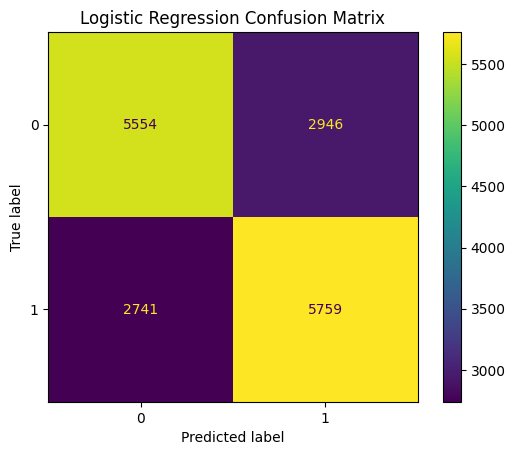

In [117]:
# Displaying confusion matrix visualization

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### 9: Random Forest Model

Random Forest was also picked as a classification model because it handles complex variable interactions really well and usually performs strongly.

We trained it using the same data sets for Logistic Regression and assessed its performance with accuracy, a confusion matrix, and F1-score, among other metrics.

In [118]:
# Importing Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Creating Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training the model

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [119]:
# Generating predictions on testing dataset

y_pred_rf = rf_model.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [120]:
# Calculating model accuracy

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:")
print(round(rf_accuracy, 4))

Random Forest Accuracy:
0.6594


In [121]:
# Creating confusion matrix

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Confusion Matrix:")
print(rf_cm)

Confusion Matrix:
[[5571 2929]
 [2861 5639]]


In [122]:
# Generating classification report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.66      0.66      0.66      8500
           1       0.66      0.66      0.66      8500

    accuracy                           0.66     17000
   macro avg       0.66      0.66      0.66     17000
weighted avg       0.66      0.66      0.66     17000



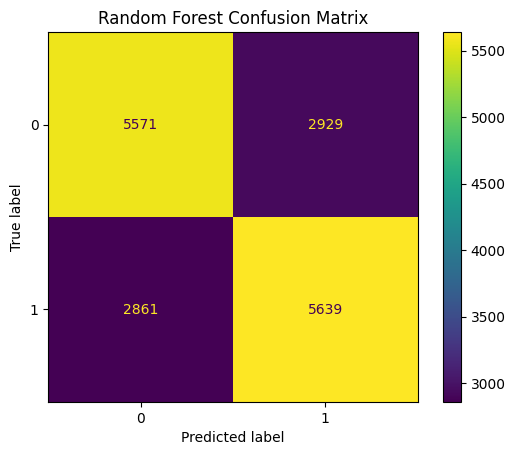

In [123]:
# Displaying confusion matrix visualization

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")

plt.show()

### 10: Model Comparison and Evaluation

We developed and assessed two models to predict loan default risk: Logistic Regression and Random Forest. We looked at accuracy, precision, recall, F1-score, and confusion matrices.

Results show that Logistic Regression did better than Random Forest on most measures. So, we picked Logistic Regression as the favored model for predicting loan defaults here.

In [124]:
# Comparing model performance

from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_log), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred_log, zero_division=0), 4),
        round(precision_score(y_test, y_pred_rf, zero_division=0), 4)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_log, zero_division=0), 4),
        round(recall_score(y_test, y_pred_rf, zero_division=0), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred_log, zero_division=0), 4),
        round(f1_score(y_test, y_pred_rf, zero_division=0), 4)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6655,0.6616,0.6775,0.6695
1,Random Forest,0.6594,0.6581,0.6634,0.6608


### 11. ROC Curve Comparison

The ROC curve is one of the most popular approaches used for evaluating binary classification models.

The ROC curve plots the True Positive Rate (or Sensitivity) vs the False Positive Rate at various classification thresholds.

Classification models having ROC curves nearer to the top left part perform better in terms of classification. The AUC metric evaluates the discriminative power of a classifier in terms of classifying a borrower either as a default or a non-default.

In our project, ROC curves will be used to evaluate the performance of logistic regression as well as random forest classifiers.



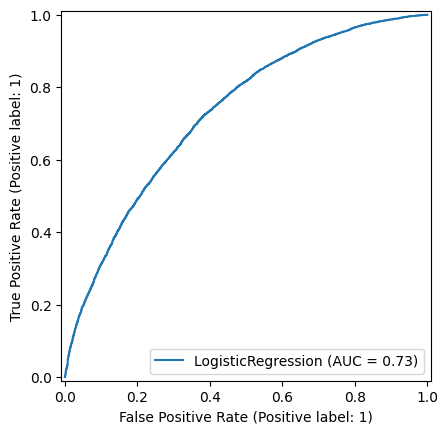

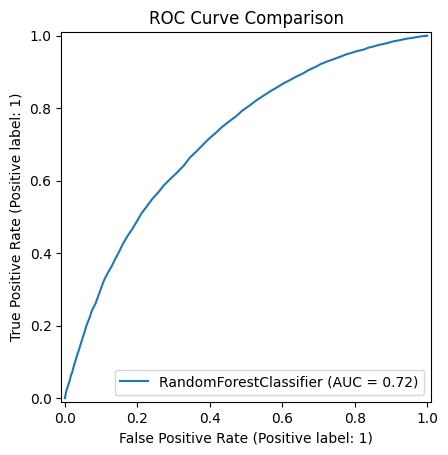

In [125]:
# ROC Curve Comparison
# This visualization compares the classification performance
# of Logistic Regression and Random Forest models.

from sklearn.metrics import RocCurveDisplay

# Plot ROC Curve for Logistic Regression

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

# Plot ROC Curve for Random Forest

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

# Add chart title

plt.title("ROC Curve Comparison")

plt.show()

## 12. Feature Importance Analysis

Feature importance analysis was carried out using the Random Forest Model.

This is because it will allow us to find which borrower and lending attributes play a major role in the prediction of credit default.

Variables having a high value for feature importance will play an important role in the prediction process.

The feature importance results help identify the strongest predictors of credit default risk and support the business recommendations in the final report.


In [126]:
# Calculate feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 important features

feature_importance.head(10)

,Feature,Importance
1,interest_rate_text,0.077530
4,debt_to_income_ratio,0.065997
9,revolving_utilization_text,0.060446
2,monthly_installment_usd,0.058745
3,annual_income_usd,0.058660
0,requested_amount_usd,0.051256
7,open_credit_lines,0.047342
6,credit_score_high,0.034544
5,credit_score_low,0.033417
10,avg_credit_score,0.033192


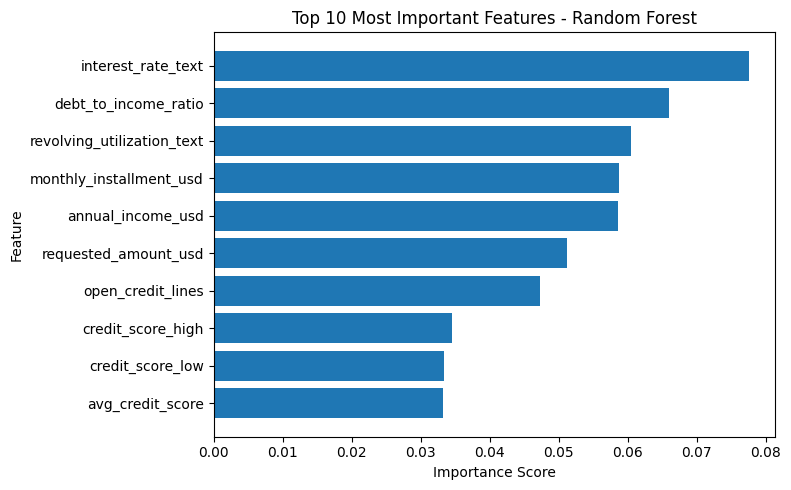

In [127]:
# Plot top 10 most important features

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### 13.Limitation

Although the models gave us helpful outcomes, the prediction accuracy was just okay, leaving some room for improvement.

We had to remove some variables to avoid data leakage, such as outcome status and the last payment amount. This made sure the final models were evaluated fairly.

For the future, we could try hyperparameter tuning, do more feature engineering, test out some fancier machine learning algorithms, and add more borrower info. These steps could bump up predictive performance and give us a better understanding of credit default risk.

### 14. Conclusion

This project used machine learning models to predict credit default risk based on borrower application info. First, we cleaned and organized the dataset by handling missing values, creating new features, turning categories into numbers, and scaling variables. We did some Exploratory Data Analysis which showed links between borrower traits and loan defaults.

We looked at two types of classification models:

Logistic Regression
Random Forest

Logistic Regression achieved the strongest overall performance, with an accuracy of about 66% and slightly higher precision, recall, and F1-score than Random Forest. The ROC curve comparison also supported Logistic Regression as the preferred model for this dataset. 

This tells us that factors like interest rates, debt-to-income ratios, loan amounts, and credit scores play a role in figuring out who's more likely to default.

In the end, our findings show that these methods can help banks spot risky borrowers and guide their lending choices with solid data.